# MedMNIST: Testing a Foundation Model, a Specialized CNN, and Fine-Tuning

MedMNIST+ is one of the easiest ways to start serious experimentation in medical imaging because it packages **18** standardized biomedical image classification datasets into a single benchmark family and adds higher-resolution variants intended for stronger representation learning and medical foundation-model research. At the same time, the broader research direction in medical imaging has shifted toward foundation models, transfer learning, and adaptation benchmarks rather than only training narrow models from scratch, which makes MedMNIST+ a good educational bridge between beginner workflows and current SoTA research.

In this notebook, 3 models for 1 MedMNIST+ subset are going to be tested:
1. Classic **ResNet** + training from scratch
2. **ViT** with transfer learning (backbone freezing) or complete fine-tuning
3. **DINOvs** (ViT base): complete frozen + fine-tuning

## 1. Install Dependencies and Imports

In [2]:
import subprocess
import sys
import os
import time
import json
import torch
from datetime import datetime
from IPython.display import display, HTML, clear_output, Markdown

packages = "medmnist timm tqdm".split(" ")
packages_torch = "torch torchvision --index-url https://download.pytorch.org/whl/cu118".split(" ")
# Install required packages
print("📦 Installing required packages...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + packages)
if float(torch.version.cuda)>11.8:
    subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "-y", "torchaudio"] + packages_torch[0:2])
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + packages_torch)
print("✅ Packages installed successfully!")

📦 Installing required packages...
✅ Packages installed successfully!


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from medmnist import INFO, Evaluator
from medmnist.dataset import PathMNIST, BloodMNIST, OCTMNIST
import timm
from tqdm import tqdm
import numpy as np
import json

torch.__version__

'2.7.1+cu118'

## 2. Setup Utility Functions

In [4]:
def display_status(message, status="info"):
    """Display colored status messages"""
    colors = {
        "info": "#3498db",
        "success": "#2ecc71",
        "warning": "#f39c12",
        "error": "#e74c3c",
        "processing": "#9b59b6"
    }
    html = f"""
    <div style="padding: 10px; margin: 10px 0; border-left: 4px solid {colors.get(status, '#3498db')}; background-color: #f8f9fa;">
        <strong style="color: {colors.get(status, '#3498db')};">{message}</strong>
    </div>
    """
    display(HTML(html))

def display_progress(current, total, label="Progress"):
    """Display a progress bar"""
    percentage = (current / total) * 100
    bar_length = 50
    filled_length = int(bar_length * current // total)
    bar = '█' * filled_length + '░' * (bar_length - filled_length)
    
    html = f"""
    <div style="margin: 10px 0;">
        <div style="font-weight: bold; margin-bottom: 5px;">{label}</div>
        <div style="background-color: #ecf0f1; border-radius: 10px; padding: 3px;">
            <div style="background-color: #3498db; width: {percentage}%; border-radius: 10px; padding: 5px; color: white; text-align: center;">
                {bar} {percentage:.1f}%
            </div>
        </div>
    </div>
    """
    display(HTML(html))

In [5]:
# ================================
# TRAINING UTILITIES
# ================================

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for imgs, labels in tqdm(loader, desc='Train', leave=False):
        imgs = imgs.to(device)
        labels = labels.to(device).long()

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc='Eval', leave=False):
            imgs = imgs.to(device)
            labels = labels.to(device).long()
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * imgs.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    acc = correct / total
    avg_loss = running_loss / total
    return avg_loss, acc, np.concatenate(all_preds), np.concatenate(all_labels)


def compute_macro_f1(y_true, y_pred, num_classes):
    """Simple macro-F1 computation."""
    # one-hot for macro F1
    y_true_oh = np.eye(num_classes)[y_true]
    y_pred_oh = np.eye(num_classes)[y_pred]
    f1s = []
    for c in range(num_classes):
        tp = ((y_pred == c) & (y_true == c)).sum()
        fp = ((y_pred == c) & (y_true != c)).sum()
        fn = ((y_pred != c) & (y_true == c)).sum()
        if tp + fp + fn == 0:
            f1s.append(0.0)
        else:
            f1s.append(2 * tp / (2 * tp + fp + fn))
    return np.mean(f1s)

In [6]:
def run_experiment(model_fn, model_name, train_loader, val_loader, test_loader, num_classes):
    print(f"\n{'='*40}")
    print(f"Running: {model_name}")
    print(f"{'='*40}")

    model = model_fn(num_classes, in_chans=3).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_val_acc = 0.0
    best_state = None
    history = []

    for epoch in range(EPOCHS):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step()

        print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
        history.append({
            'epoch': epoch+1,
            'train_loss': float(train_loss),
            'train_acc': float(train_acc),
            'val_loss': float(val_loss),
            'val_acc': float(val_acc)
        })

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = model.state_dict().copy()

    # Load best and evaluate on test
    if best_state is not None:
        model.load_state_dict(best_state)

    test_loss, test_acc, y_pred, y_true = evaluate(model, test_loader, criterion, DEVICE)
    test_f1 = compute_macro_f1(y_true, y_pred, num_classes)

    print(f"Test Accuracy: {test_acc:.4f} | Test Macro-F1: {test_f1:.4f}")

    return {
        'model': model_name,
        'test_acc': float(test_acc),
        'test_macro_f1': float(test_f1),
        'best_val_acc': float(best_val_acc),
        'history': history
    }

## 3. Setup for reproducibility
We chose an image size of *128x128*.

In [7]:
# ================================
# CONFIGURATION
# ================================

DATA_FLAG = 'bloodmnist'          # Change to 'bloodmnist', 'octmnist', 'breastmist', 'pathmnist', etc.
SIZE = 28                       # MedMNIST+ supports 64, 128, 224 for 2D
BATCH_SIZE = 128
EPOCHS = 20
LR = 1e-3
WEIGHT_DECAY = 1e-5
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

display_status("🚀 Device: " + str(DEVICE).upper() + " " \
               + torch.version.cuda if torch.cuda.is_available() else "" , "processing")


# ================================
# DATA LOADING
# ================================

def get_dataloaders(data_flag, size, batch_size, transform=None):
    """Load MedMNIST+ dataset with the specified resolution."""
    info = INFO[data_flag]
    DataClass = getattr(__import__('medmnist.dataset', fromlist=[info['python_class']]), info['python_class'])

    # Note: MedMNIST+ images at size 28,64,128,224 are loaded directly
    train_dataset = DataClass(split='train', download=True, size=size)
    val_dataset = DataClass(split='val', download=True, size=size)
    test_dataset = DataClass(split='test', download=True, size=size)

    # MedMNIST images come as PIL or numpy in [0,255] or [0,1]
    # We'll use ToTensor and Normalize for pretrained models
    if not transform:
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[.5], std=[.5])  # scale to [-1, 1]
        ])

    # Wrap datasets with transform
    # MedMNIST dataset returns (img, label) where img is PIL or ndarray
    # We'll apply transform in collate or override __getitem__
    # Simpler: use standard approach with a small wrapper
    class TransformedDataset(torch.utils.data.Dataset):
        def __init__(self, base_dataset, transform):
            self.base = base_dataset
            self.transform = transform
            
        def __len__(self):
            return len(self.base)
            
        def __getitem__(self, idx):
            img, label = self.base[idx]
            if self.transform:
                img = self.transform(img)
            # label might be array, take scalar
            if isinstance(label, np.ndarray):
                label = label.item()
            return img, label

    train_ds = TransformedDataset(train_dataset, transform)
    val_ds = TransformedDataset(val_dataset, transform)
    test_ds = TransformedDataset(test_dataset, transform)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, persistent_workers=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2)

    return train_loader, val_loader, test_loader, info


### Data Loading

In [8]:
display_status(f"Dataset subset: {DATA_FLAG}, Size: {SIZE}, Batch Size: {BATCH_SIZE}" , "info")

display_status("Extracting Dataset", 'processing')
train_loader, val_loader, test_loader, info = get_dataloaders(DATA_FLAG, SIZE, BATCH_SIZE)
num_classes = len(info['label'])
display_status(f"Dataset Extracted -> # Classes: {num_classes}", 'success')

100%|██████████| 35.5M/35.5M [00:16<00:00, 2.21MB/s]


### Visualization

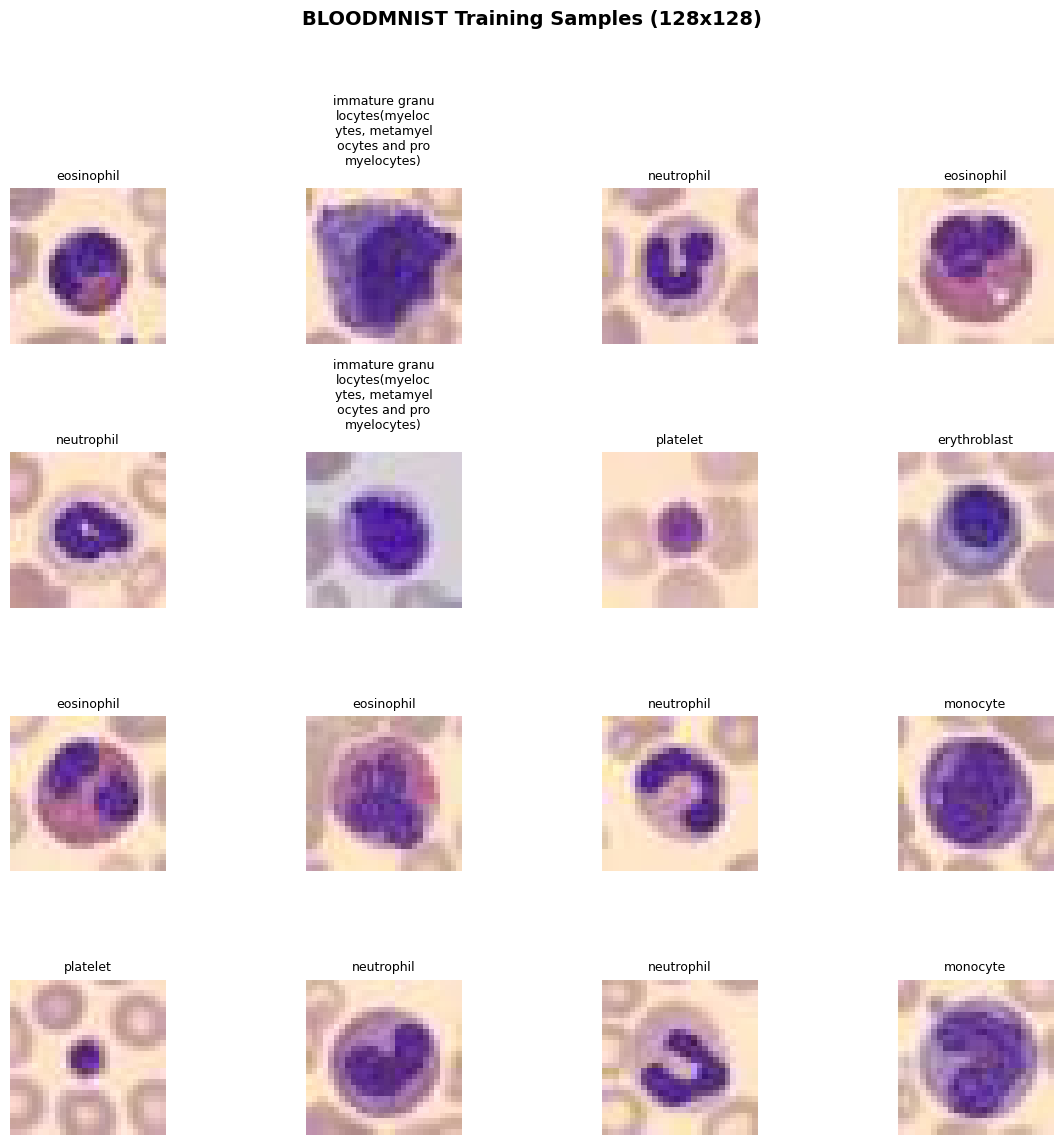

Saved to output/dataset_visualization.png


In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from medmnist import INFO
from medmnist.dataset import BloodMNIST


def visualize_dataset_samples(dataset, num_images=16, figsize=(12, 12), 
                              class_names=None, title="Dataset Samples", 
                              save_path="output/dataset_visualization.png"):
    """
    Visualize random samples from a MedMNIST+ dataset with class labels.
    num_images should be a perfect square (e.g., 9, 16, 25) for a clean grid.
    """
    grid_size = int(np.ceil(np.sqrt(num_images)))
    fig, axes = plt.subplots(grid_size, grid_size, figsize=figsize)
    axes = axes.flatten()
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for idx in range(num_images):
        ax = axes[idx]
        
        # Random sample
        sample_idx = np.random.randint(0, len(dataset))
        img, label = dataset[sample_idx]
        
        # Convert to numpy for display
        if isinstance(img, torch.Tensor):
            img_np = img.numpy()
        elif isinstance(img, np.ndarray):
            img_np = img
        else:
            img_np = np.array(img)
        
        # MedMNIST images are (C, H, W) after ToTensor; convert to (H, W, C)
        if img_np.ndim == 3 and img_np.shape[0] in [1, 3]:
            img_np = np.transpose(img_np, (1, 2, 0))
        
        # Squeeze single-channel dimension
        if img_np.ndim == 3 and img_np.shape[-1] == 1:
            img_np = img_np.squeeze(-1)
        
        # Normalize if pixel values are in [0, 255]
        if img_np.max() > 1.5:
            img_np = img_np / 255.0
        
        # Display
        cmap = 'gray' if img_np.ndim == 2 else None
        ax.imshow(img_np, cmap=cmap)
        
        # Label
        label_val = label.item() if hasattr(label, 'item') else int(label)
        label_str = class_names[label_val] if class_names else f"Class {label_val}"
        max_s = 15
        if len(label_str) > max_s:
            new_label = ""
            for l in range(0, len(label_str), max_s-1):
                new_label += label_str[l:l+max_s-1] + "\n"
                # print(len(new_label), l, l+max_s-1, len(label_str))
            label_str = new_label
        ax.set_title(label_str, fontsize=9)
        ax.axis('off')
    
    # Hide unused subplots
    for idx in range(num_images, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    # plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved to {save_path}")


# --- Usage ---
info = INFO[DATA_FLAG]
class_names = list(info['label'].values())  # e.g., ['adipose', 'background', ...]

train_dataset = BloodMNIST(split='train', download=True, size=SIZE)
visualize_dataset_samples(train_dataset, num_images=16, class_names=class_names,
                          title=f"{DATA_FLAG.upper()} Training Samples (128x128)")

## 4. Resnet
The first baseline model is a compact convolutional neural network trained only on the target dataset. A **ResNet-18** is an interesting starting point because it is small, fast, and still strong enough to provide a real baseline. In the article, this model can be framed as the specialized approach: no broad pretraining, no external representation bank, only supervised learning on the medical task itself.

This setup teaches readers several important lessons. First, it shows the natural performance ceiling of a straightforward medical imaging pipeline. Second, it highlights how quickly small medical datasets can overfit. Third, it gives a realistic comparison point for later transfer-learning results.

In [10]:
def build_resnet18(num_classes, in_chans=3):
    """Standard ResNet-18 from torchvision for medical image classification."""
    from torchvision.models import resnet18
    model = resnet18(weights=None)  # trained from scratch
    # Adjust first conv if needed (MedMNIST is grayscale but we can repeat channels)
    if in_chans == 1:
        print(in_chans)
        model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


# resnet_model = build_resnet18(num_classes)
#resnet_model

resnet_result = run_experiment(build_resnet18, "ResNet-18 (from scratch)",
                                  train_loader, val_loader, test_loader, num_classes)


Running: ResNet-18 (from scratch)


Epoch 1/20 | Train Loss: 0.5803 Acc: 0.7869 | Val Loss: 0.4707 Acc: 0.8201


Epoch 2/20 | Train Loss: 0.3497 Acc: 0.8747 | Val Loss: 0.7018 Acc: 0.7582


Epoch 3/20 | Train Loss: 0.2944 Acc: 0.8926 | Val Loss: 0.5647 Acc: 0.7786


Epoch 4/20 | Train Loss: 0.2423 Acc: 0.9097 | Val Loss: 0.5364 Acc: 0.8242


...

Epoch 17/20 | Train Loss: 0.0038 Acc: 0.9990 | Val Loss: 0.2068 Acc: 0.9474


Epoch 18/20 | Train Loss: 0.0029 Acc: 0.9996 | Val Loss: 0.1850 Acc: 0.9509


Epoch 19/20 | Train Loss: 0.0023 Acc: 0.9997 | Val Loss: 0.1880 Acc: 0.9509


Epoch 20/20 | Train Loss: 0.0019 Acc: 0.9999 | Val Loss: 0.1855 Acc: 0.9539


Test Accuracy: 0.9512 | Test Macro-F1: 0.9460


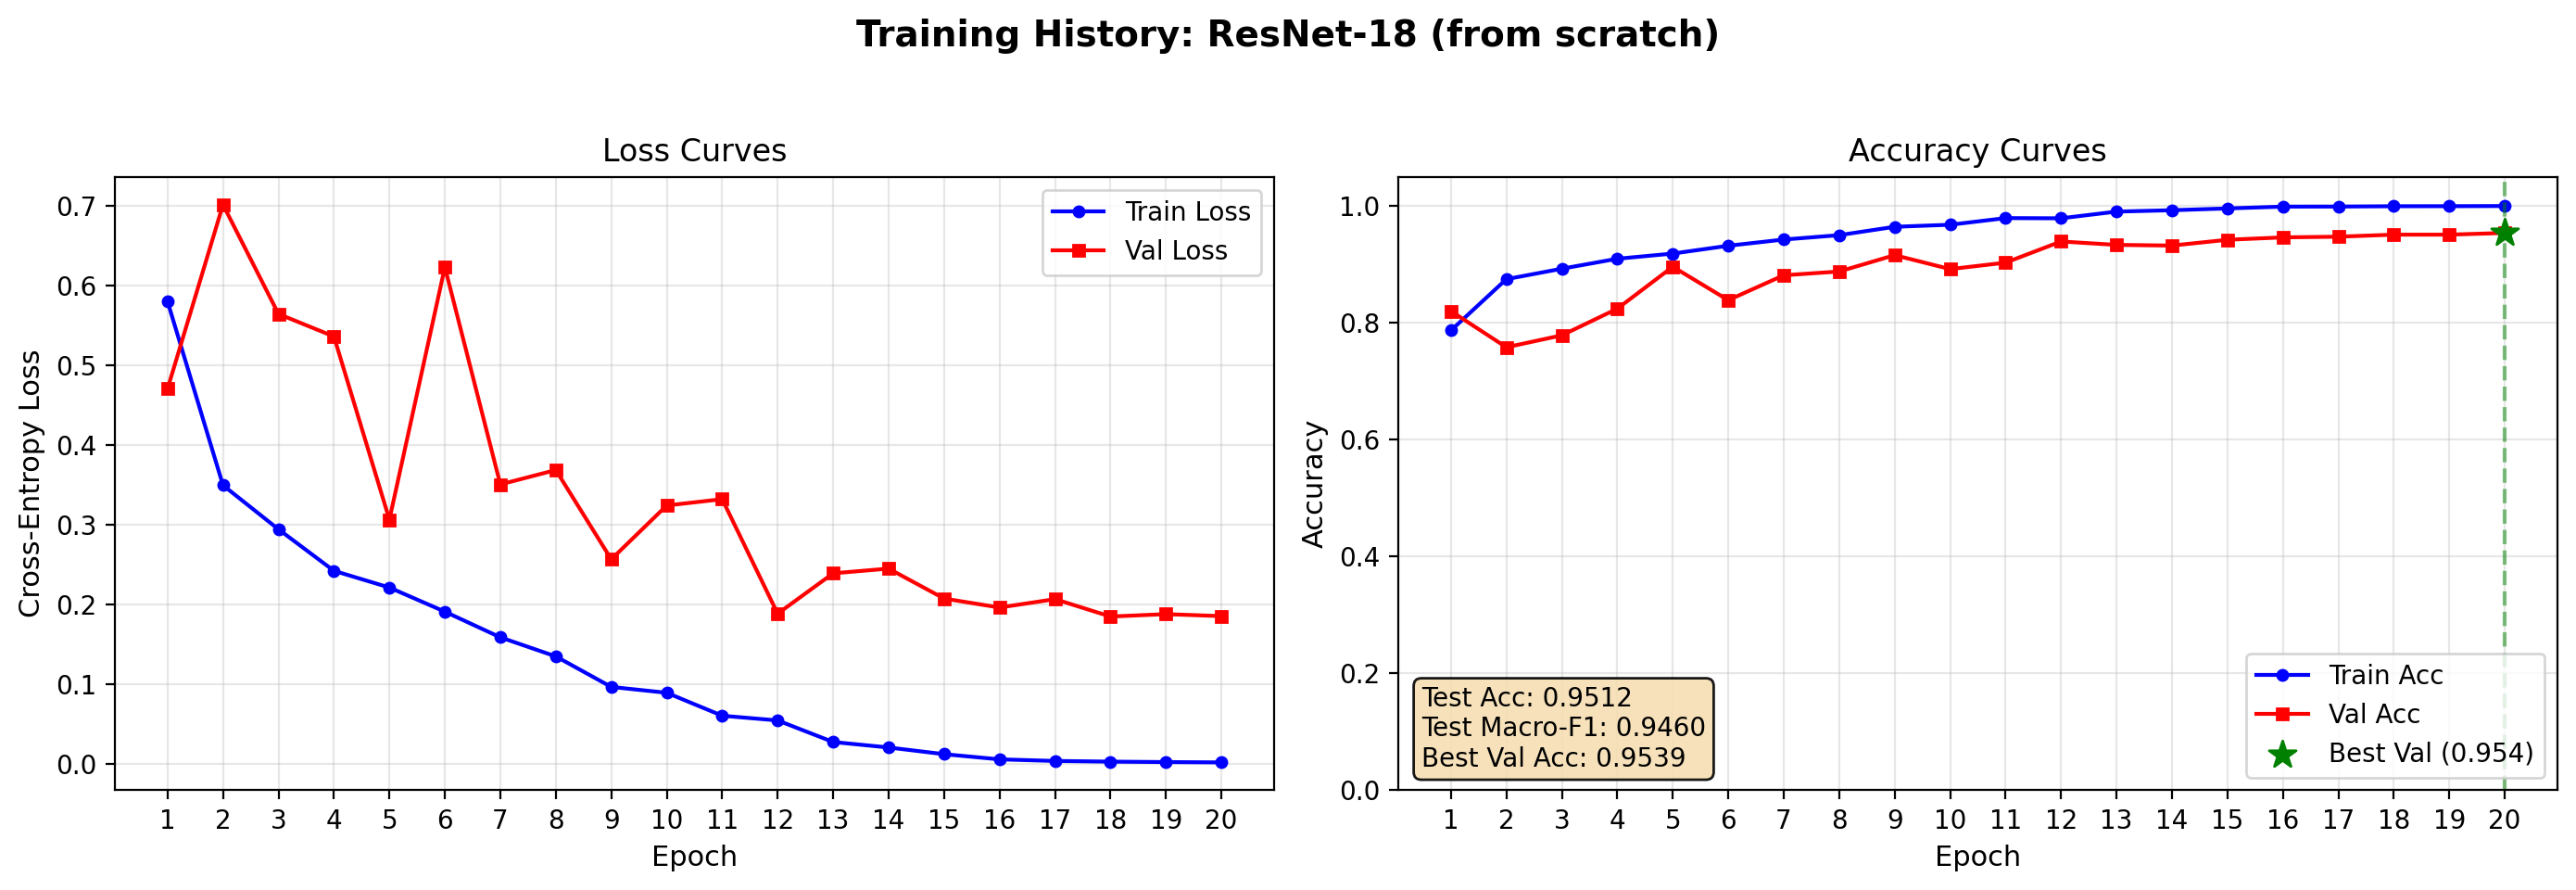

Saved plot to output/resnet_curves.png


In [11]:

def plot_training_history(result_dict, save_path="output/training_curves.png", 
                          figsize=(14, 5)):
    """
    Plot training curves from the dict returned by run_experiment().
    
    Args:
        result_dict: dict with keys 'model', 'test_acc', 'test_macro_f1',
                     'best_val_acc', 'history' (list of per-epoch dicts)
        save_path:   path for the PNG output
        figsize:     matplotlib figure size
    """
    history = result_dict['history']
    epochs  = [h['epoch'] for h in history]
    
    train_loss = [h['train_loss'] for h in history]
    val_loss   = [h['val_loss']   for h in history]
    train_acc  = [h['train_acc']  for h in history]
    val_acc    = [h['val_acc']    for h in history]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, dpi=200)
    fig.suptitle(f"Training History: {result_dict['model']}", 
                 fontsize=14, fontweight='bold')
    
    # --- Loss ---
    ax1.plot(epochs, train_loss, 'b-o', label='Train Loss', 
             markersize=4, linewidth=1.5)
    ax1.plot(epochs, val_loss,   'r-s', label='Val Loss',   
             markersize=4, linewidth=1.5)
    ax1.set_xlabel('Epoch', fontsize=11)
    ax1.set_ylabel('Cross-Entropy Loss', fontsize=11)
    ax1.set_title('Loss Curves')
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks(epochs)
    
    # --- Accuracy ---
    ax2.plot(epochs, train_acc, 'b-o', label='Train Acc', 
             markersize=4, linewidth=1.5)
    ax2.plot(epochs, val_acc,   'r-s', label='Val Acc',   
             markersize=4, linewidth=1.5)
    
    # Mark best validation epoch
    best_epoch_idx = val_acc.index(max(val_acc))
    best_epoch     = epochs[best_epoch_idx]
    best_val       = val_acc[best_epoch_idx]
    ax2.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.5)
    ax2.scatter([best_epoch], [best_val], color='green', s=120, 
                zorder=5, marker='*', label=f'Best Val ({best_val:.3f})')
    
    # Test metrics box (top-left, inside axes)
    textstr = (f"Test Acc: {result_dict['test_acc']:.4f}\n"
               f"Test Macro-F1: {result_dict['test_macro_f1']:.4f}\n"
               f"Best Val Acc: {result_dict['best_val_acc']:.4f}")
    ax2.text(0.02, 0.17, textstr, transform=ax2.transAxes, fontsize=10,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))
    
    ax2.set_xlabel('Epoch', fontsize=11)
    ax2.set_ylabel('Accuracy', fontsize=11)
    ax2.set_title('Accuracy Curves')
    ax2.legend(loc='lower right')
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks(epochs)
    ax2.set_ylim([0.0, 1.05])
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    # plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved plot to {save_path}")



plot_training_history(resnet_result, save_path="output/resnet_curves.png")

## 5. ViT: Foundation Model
The second setup should use a pretrained vision transformer encoder as a foundation model, keeping the encoder frozen and training only a lightweight classification head. This is the simplest way to test whether broad visual pretraining already captures features that transfer to medical imagery.

Conceptually, this setup asks a useful question: can general visual representations classify pathology before any task-specific adaptation? That question aligns well with the current direction of medical imaging benchmarks, where model transfer and adaptation quality are increasingly central evaluation themes rather than optional extras.

### ❄️ Frozen 

In [14]:
def build_vit_frozen(num_classes, in_chans=3):
    """Pretrained ViT from timm with backbone frozen."""
    # Using vit_base_patch16_224.augreg_in21k is common, but for 128 images we use
    # a smaller model for speed: vit_tiny_patch16_224 or deit_tiny
    model = timm.create_model('vit_tiny_patch16_224.augreg_in21k', pretrained=True, num_classes=0)
    # Freeze backbone
    for param in model.parameters():
        param.requires_grad = False
    # Replace/add head
    in_features = model.num_features
    model.head = nn.Linear(in_features, num_classes)
    return model

model = timm.create_model('vit_tiny_patch16_224.augreg_in21k_ft_in1k', pretrained=True)
model = model.eval()

# get model specific transforms (normalization, resize)
data_config = timm.data.resolve_model_data_config(model)
transform_vit = timm.data.create_transform(**data_config, is_training=False)

train_loader, val_loader, test_loader, info = get_dataloaders(DATA_FLAG, SIZE, BATCH_SIZE, transform_vit)


vit_frozen_res = run_experiment(build_vit_frozen, "ViT-Tiny (frozen backbone)",
                                  train_loader, val_loader, test_loader, num_classes)


Running: ViT-Tiny (frozen backbone)


Epoch 1/20 | Train Loss: 1.3019 Acc: 0.5786 | Val Loss: 0.7162 Acc: 0.7728


Epoch 2/20 | Train Loss: 0.6289 Acc: 0.7987 | Val Loss: 0.5378 Acc: 0.8289


Epoch 3/20 | Train Loss: 0.5102 Acc: 0.8347 | Val Loss: 0.4693 Acc: 0.8470


Epoch 4/20 | Train Loss: 0.4555 Acc: 0.8517 | Val Loss: 0.4323 Acc: 0.8540


...

Epoch 17/20 | Train Loss: 0.3186 Acc: 0.8945 | Val Loss: 0.3182 Acc: 0.8867


Epoch 18/20 | Train Loss: 0.3175 Acc: 0.8946 | Val Loss: 0.3183 Acc: 0.8879


Epoch 19/20 | Train Loss: 0.3168 Acc: 0.8947 | Val Loss: 0.3175 Acc: 0.8855


Epoch 20/20 | Train Loss: 0.3163 Acc: 0.8949 | Val Loss: 0.3173 Acc: 0.8861


Test Accuracy: 0.8875 | Test Macro-F1: 0.8676


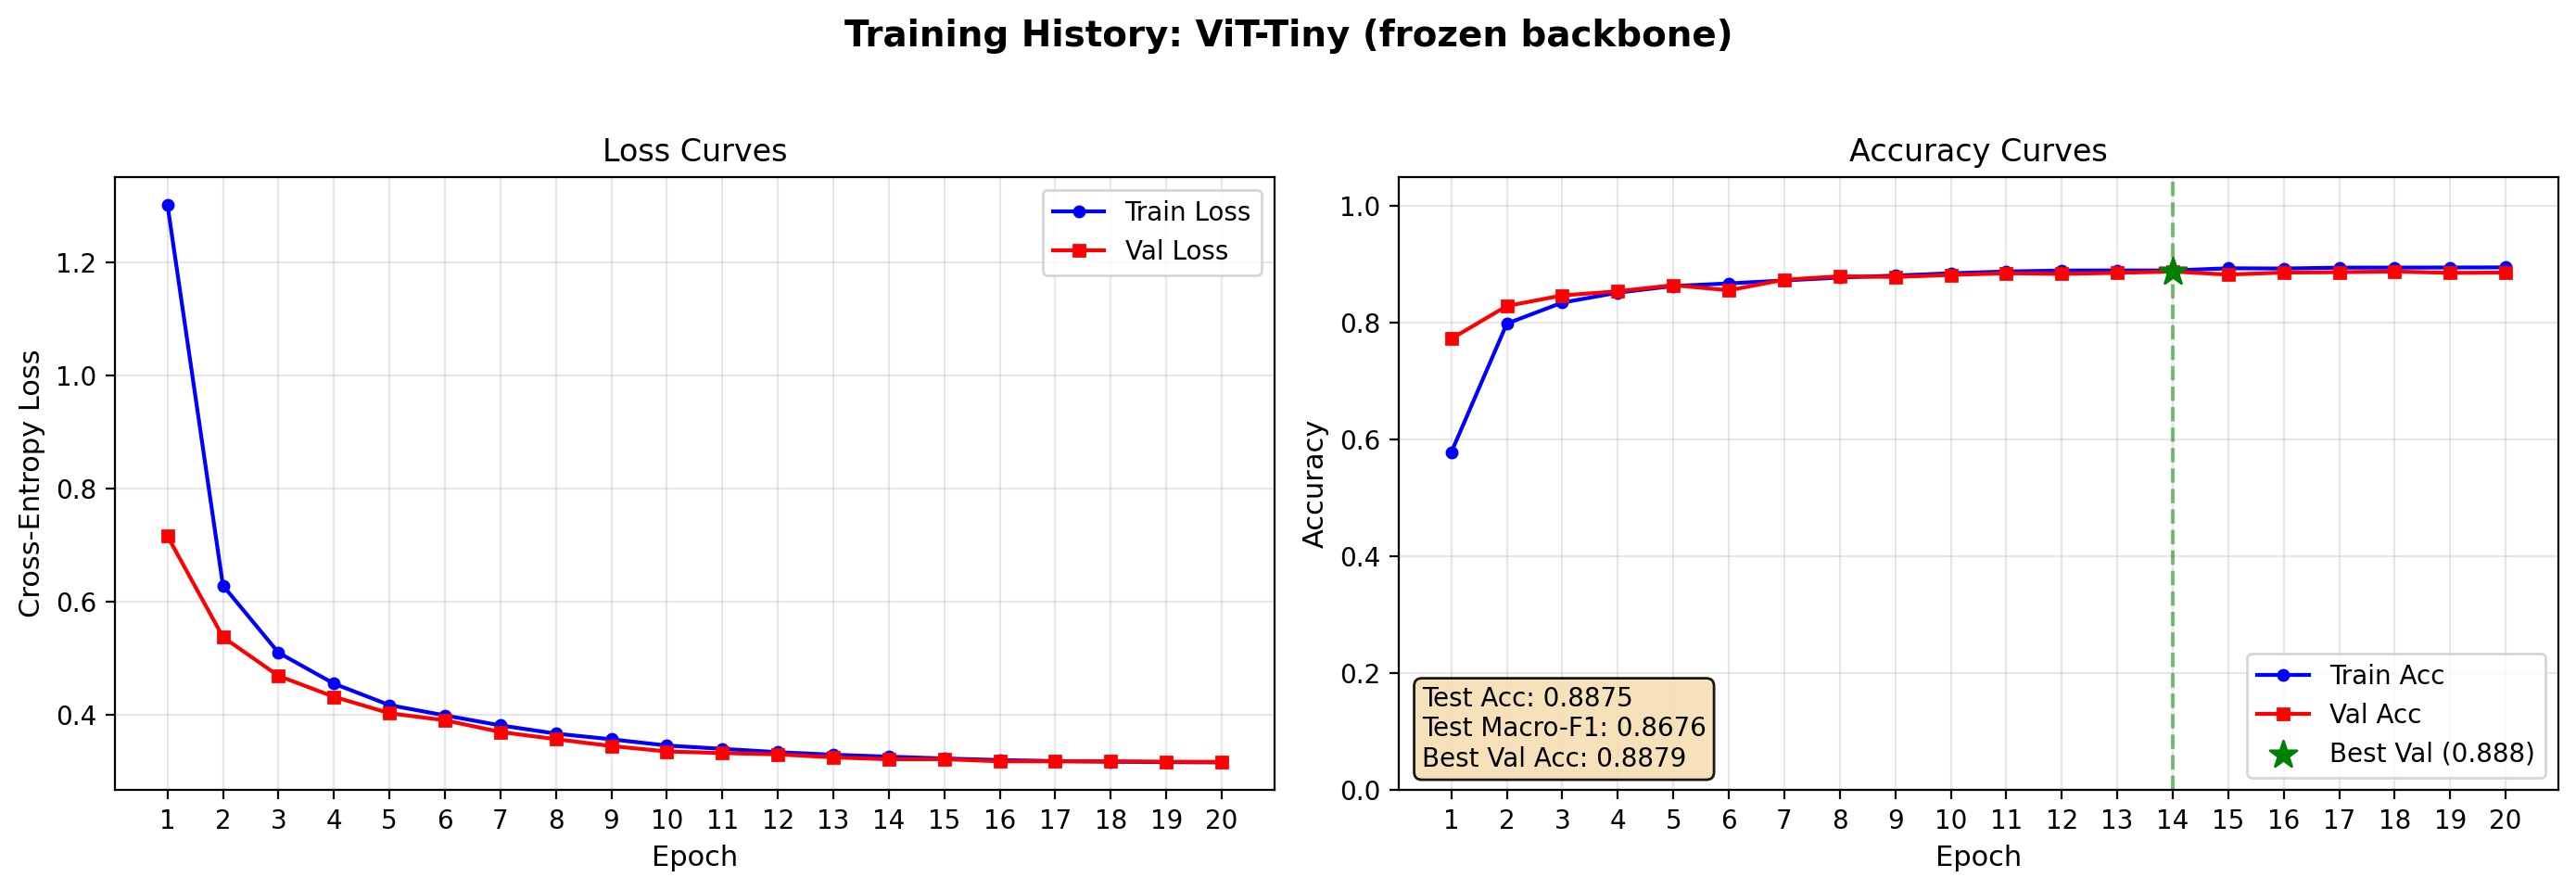

Saved plot to output/resnet_curves.png


In [15]:
plot_training_history(vit_frozen_res, save_path="output/resnet_curves.png")

### ⚙️ Fine-Tuned
The third setup should reuse the same pretrained encoder but unfreeze some or all of the backbone for end-to-end fine-tuning. This is usually the most informative configuration because it reveals whether the pretrained representation is already sufficient as-is or whether the target task needs domain adaptation.

This configuration often performs best in practice when the dataset is large enough to support stable updates. It also creates the clearest narrative for readers: a frozen foundation model offers speed and simplicity, while fine-tuning trades extra compute and tuning effort for stronger task alignment.

In [16]:
def build_vit_finetune(num_classes, in_chans=3):
    """Pretrained ViT from timm with all layers trainable."""
    model = timm.create_model('vit_tiny_patch16_224.augreg_in21k', pretrained=True, num_classes=0)
    in_features = model.num_features
    model.head = nn.Linear(in_features, num_classes)
    return model

# train_loader, val_loader, test_loader, info = get_dataloaders(DATA_FLAG, SIZE, BATCH_SIZE, transforms)

vit_finetune_res = run_experiment(build_vit_finetune, "ViT-Tiny (fine-tuned)",
                                  train_loader, val_loader, test_loader, num_classes)


Running: ViT-Tiny (fine-tuned)


Epoch 1/20 | Train Loss: 1.6863 Acc: 0.4445 | Val Loss: 0.7338 Acc: 0.7366


Epoch 2/20 | Train Loss: 0.5881 Acc: 0.7836 | Val Loss: 0.3984 Acc: 0.8645


Epoch 3/20 | Train Loss: 0.3863 Acc: 0.8606 | Val Loss: 0.3008 Acc: 0.8826


Epoch 4/20 | Train Loss: 0.2958 Acc: 0.8956 | Val Loss: 0.2862 Acc: 0.8855


...

Epoch 17/20 | Train Loss: 0.0035 Acc: 0.9993 | Val Loss: 0.2031 Acc: 0.9568


Epoch 18/20 | Train Loss: 0.0014 Acc: 0.9998 | Val Loss: 0.2056 Acc: 0.9562


Epoch 19/20 | Train Loss: 0.0010 Acc: 1.0000 | Val Loss: 0.2068 Acc: 0.9568


Epoch 20/20 | Train Loss: 0.0009 Acc: 1.0000 | Val Loss: 0.2074 Acc: 0.9568


Test Accuracy: 0.9611 | Test Macro-F1: 0.9563


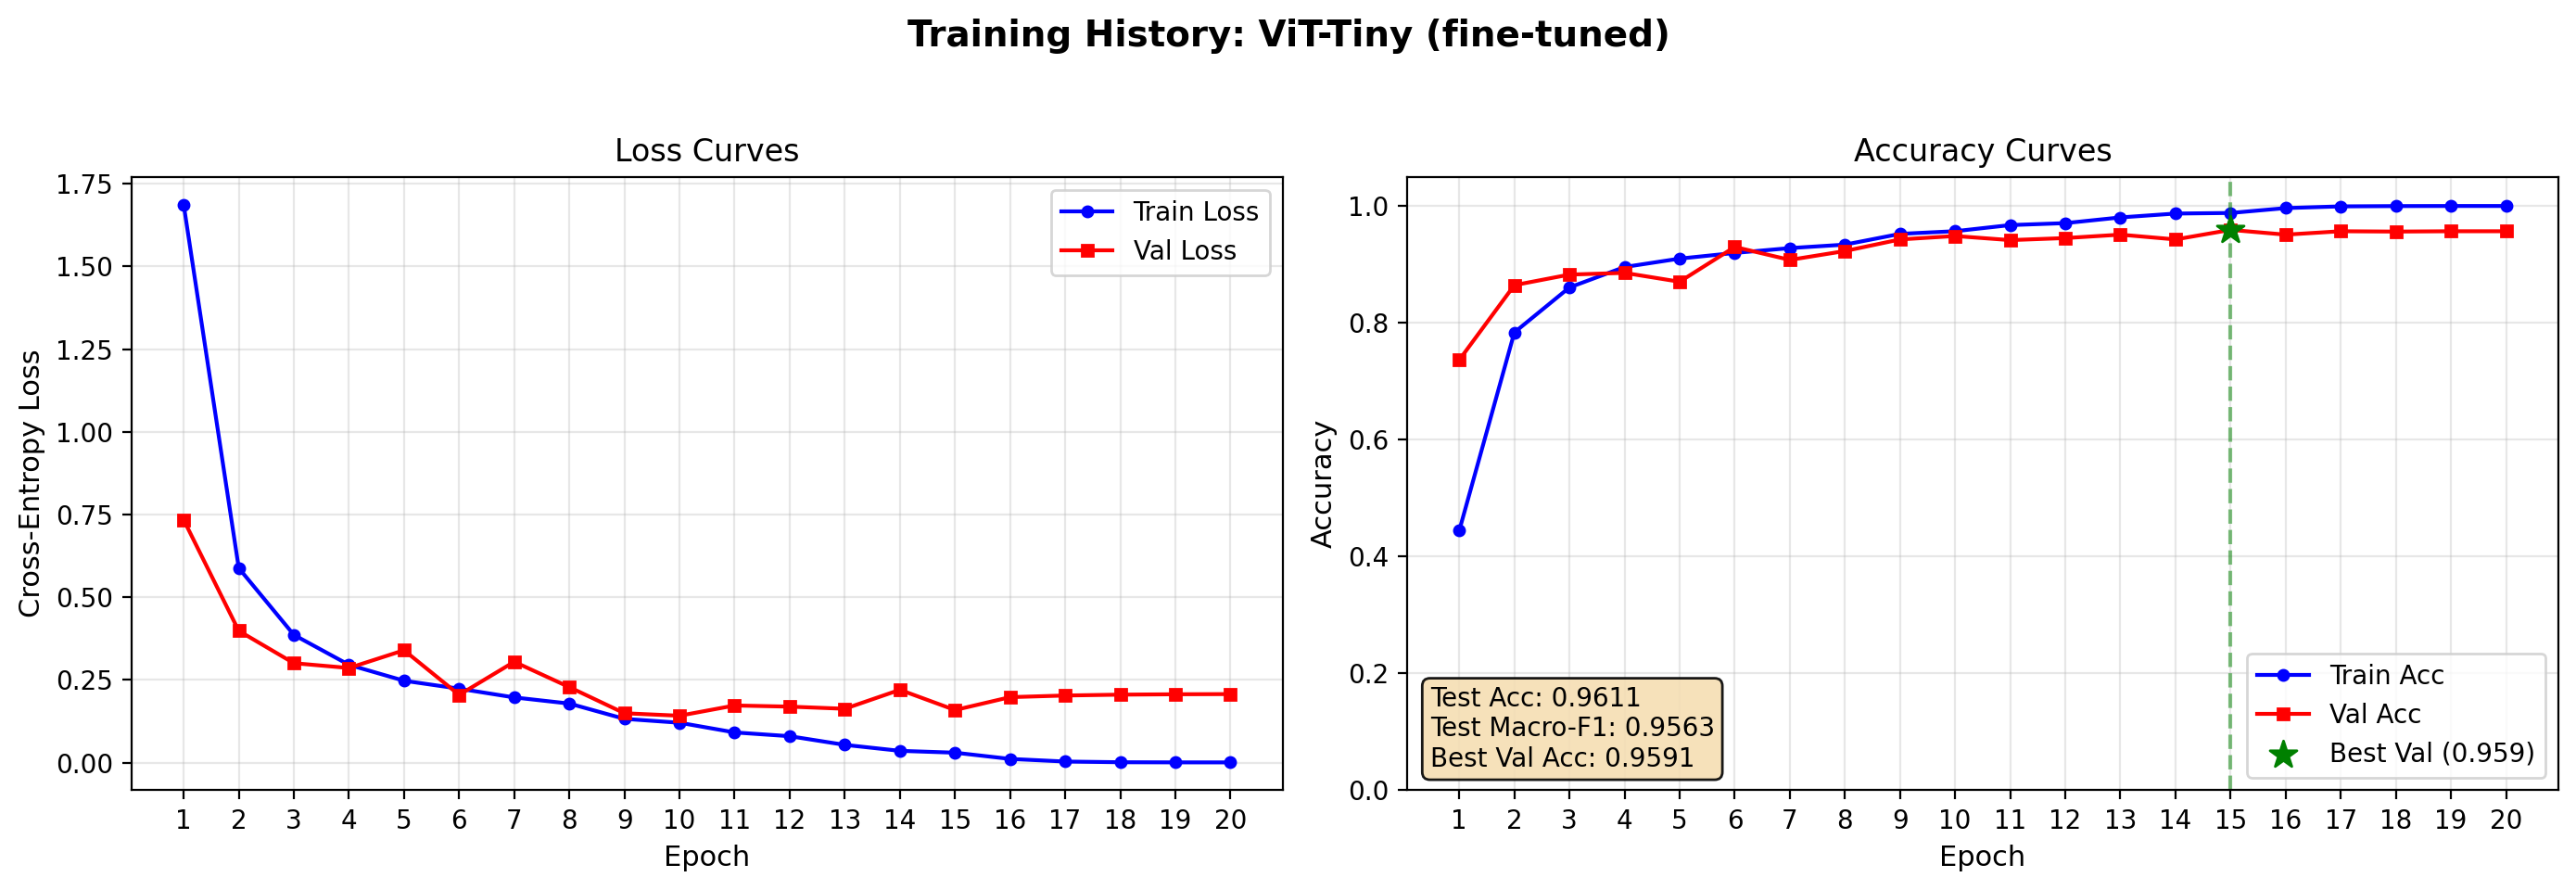

Saved plot to output/resnet_curves.png


In [17]:
plot_training_history(vit_finetune_res, save_path="output/resnet_curves.png")

ViT fine-tuned perform slightly better results (95.5% accuracy vs 94% of ResNet) but provides higher accuracy when compared with the frozen-backbone training.

## 6. DINOv2
In order to get closer to SoTa model, we test DINOv2 (v3 has restricted access from META, so not everyone can use it yet).

In [18]:
import timm
from timm.data import resolve_model_data_config, create_transform
from torchvision import transforms


class DINOv2Classifier(nn.Module):
    def __init__(self, model_name, num_classes, freeze_backbone=True, img_size=None):
        super().__init__()
        
        # num_classes=0 removes the original classifier head
        # DINOv2 then outputs (batch_size, num_features) directly
        self.backbone = timm.create_model(
            model_name,
            pretrained=True,
            num_classes=0,
            img_size=img_size
        )
        
        # Freeze all backbone parameters
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
        
        # DINOv2 exposes num_features (384 for small, 768 for base)
        feat_dim = self.backbone.num_features
        self.head = nn.Linear(feat_dim, num_classes)
        
        print(f"[DINOv2Classifier] Backbone: {model_name}")
        print(f"\tFeature dim: {feat_dim}")
        print(f"\tBackbone frozen: {freeze_backbone}")
        print(f"\timg_size: {img_size}")

    def forward(self, x):
        # backbone(x) returns (B, num_features)
        features = self.backbone(x)
        return self.head(features)


# Builder functions for your training pipeline

def build_dinov2_frozen(num_classes, in_chans=3, img_size=224):
    """Frozen DINOv2-Small: only linear head trained. Fast, good baseline."""
    return DINOv2Classifier(
        model_name="vit_small_patch14_dinov2.lvd142m",
        num_classes=num_classes,
        freeze_backbone=True,
        img_size=img_size
    )


def build_dinov2_finetune(num_classes, in_chans=3, img_size=224):
    """Fine-tunable DINOv2-Small: all 22M parameters trainable."""
    return DINOv2Classifier(
        model_name="vit_small_patch14_dinov2.lvd142m",
        num_classes=num_classes,
        freeze_backbone=False,
        img_size=img_size
    )

model = timm.create_model(
    'vit_small_patch14_dinov2.lvd142m',
    pretrained=True,
    num_classes=0,  
    img_size=224,# remove classifier nn.Linear
)
model = model.eval()

# get model specific transforms (normalization, resize)
data_config = timm.data.resolve_model_data_config(model)
transform_dino = timm.data.create_transform(**data_config, is_training=False)

# use DINOv2 last transformation for normalization
transform_dino = transforms.Compose(transform_vit.transforms[:-1] + [transform_dino.transforms[-1]])

train_loader, val_loader, test_loader, info = get_dataloaders(DATA_FLAG, SIZE, BATCH_SIZE, transform_dino)

dinov2_frozen_res = run_experiment(
    build_dinov2_frozen, "DINOv2-Small (frozen)",
    train_loader, val_loader, test_loader, num_classes 
)

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]


Running: DINOv2-Small (frozen)
[DINOv2Classifier] Backbone: vit_small_patch14_dinov2.lvd142m
	Feature dim: 384
	Backbone frozen: True
	img_size: 224


Epoch 1/20 | Train Loss: 1.0284 Acc: 0.6613 | Val Loss: 0.5685 Acc: 0.8435


Epoch 2/20 | Train Loss: 0.5159 Acc: 0.8470 | Val Loss: 0.4277 Acc: 0.8803


Epoch 3/20 | Train Loss: 0.4134 Acc: 0.8760 | Val Loss: 0.3547 Acc: 0.8931


...

Epoch 17/20 | Train Loss: 0.2356 Acc: 0.9249 | Val Loss: 0.2320 Acc: 0.9241


Epoch 18/20 | Train Loss: 0.2338 Acc: 0.9251 | Val Loss: 0.2305 Acc: 0.9223


Epoch 19/20 | Train Loss: 0.2332 Acc: 0.9258 | Val Loss: 0.2296 Acc: 0.9246


Epoch 20/20 | Train Loss: 0.2325 Acc: 0.9262 | Val Loss: 0.2293 Acc: 0.9241


Test Accuracy: 0.9184 | Test Macro-F1: 0.9047


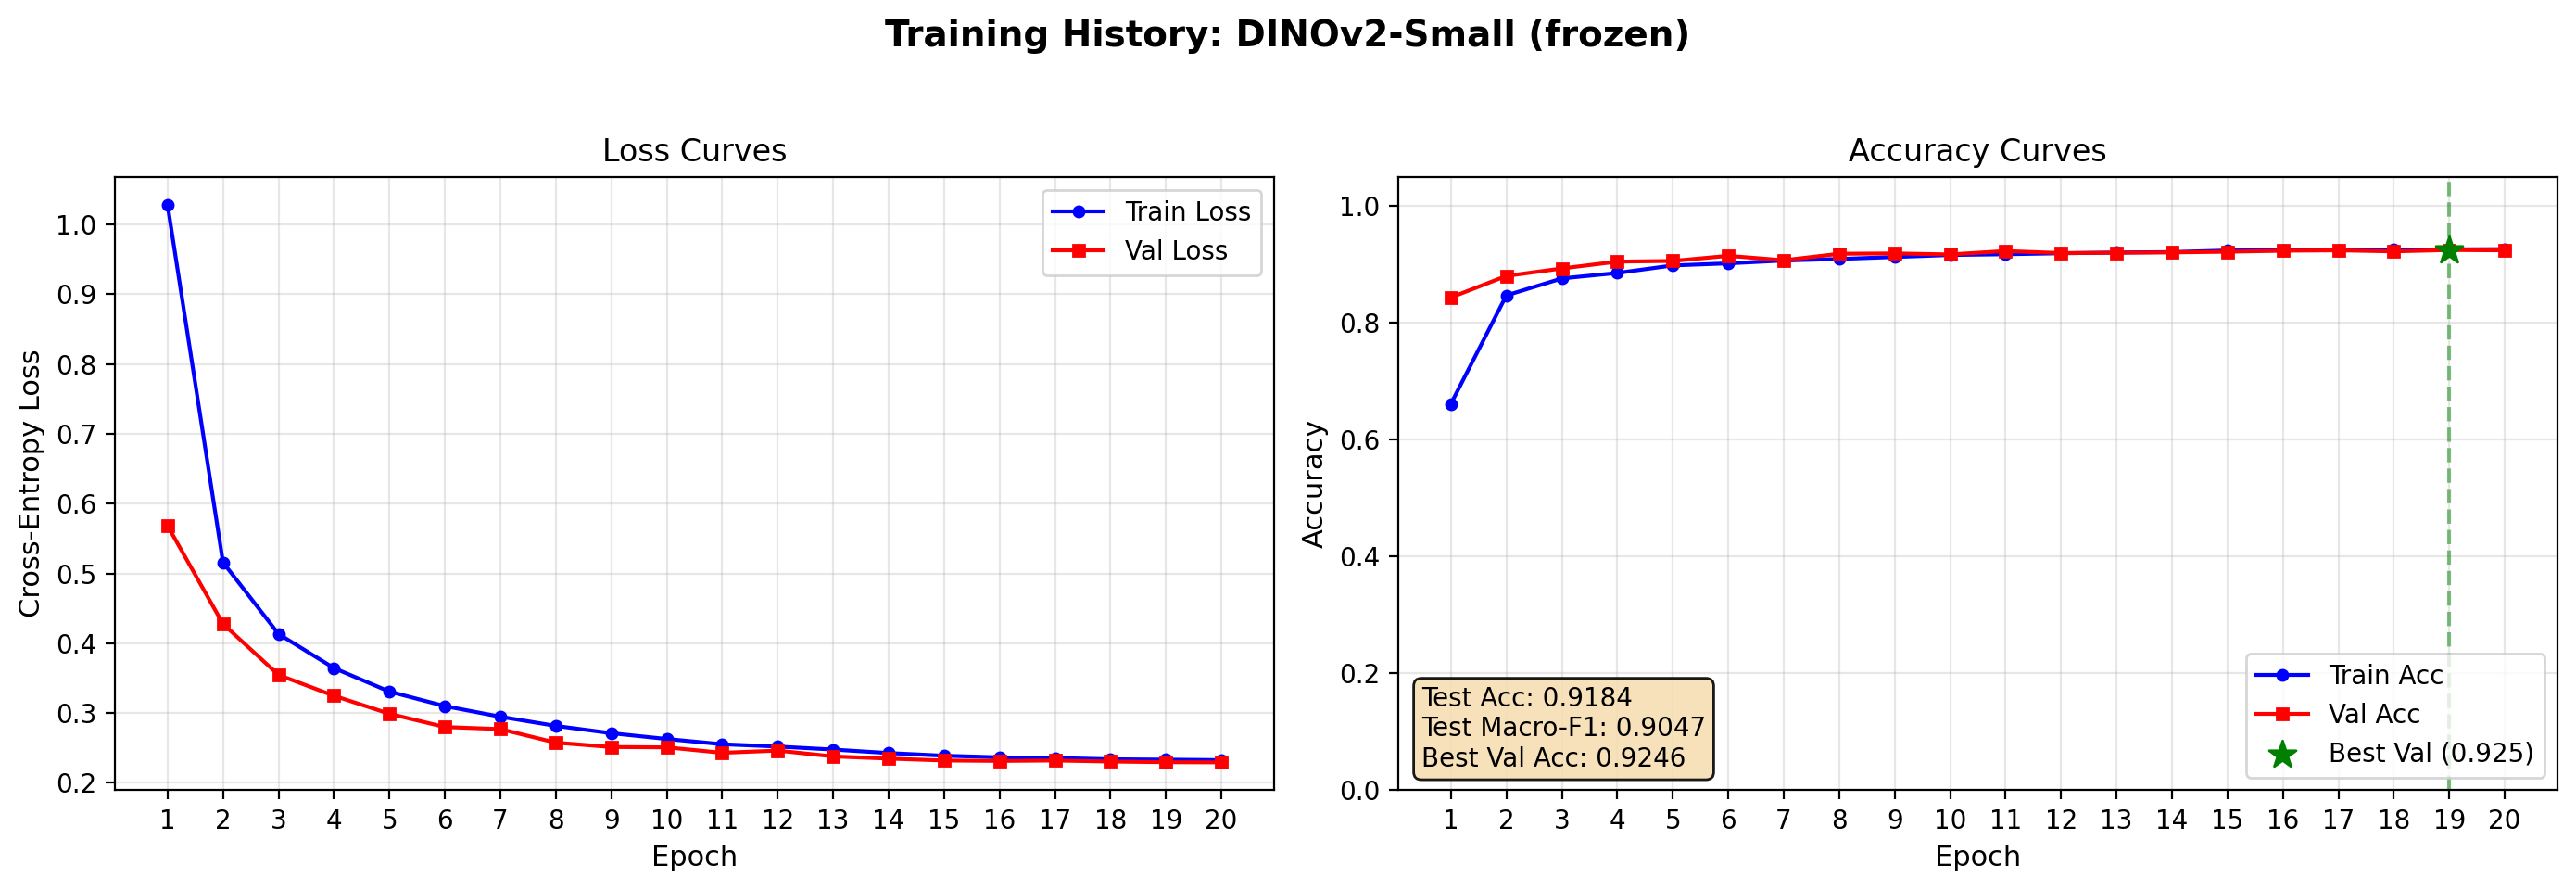

Saved plot to output/dinov2_frozen_curves.png


In [19]:
plot_training_history(dinov2_frozen_res, save_path="output/dinov2_frozen_curves.png")

In [ ]:

# train_loader, val_loader, test_loader, info = get_dataloaders(DATA_FLAG, SIZE, BATCH_SIZE, transform_dino)

# # Fine-tuned DINOv2
# dinov2_finetune_res = run_experiment(
#     build_dinov2_finetune, "DINOv2-Small (fine-tuned)",
#     train_loader, val_loader, test_loader, num_classes
# )

In [ ]:
# plot_training_history(dinov2_finetune_res, save_path="output/dinov2_frozen_curves.png")

Complete fine-tuning of DINOv2 performs slighlty better than the frozen one, however lower than ViT and ResNet. Moreover, the training time is much larger (3-5 times slower) than the previous cases.
It should be tested with higher resolution since it is a much more complex model.

## 7. Results and Discussion

On BloodMNIST, a nine-class hematology classification task from MedMNIST+, three modeling strategies were evaluated: a classical ResNet-18 trained from scratch, a supervised Vision Transformer with frozen and fine-tuned backbones, and a self-supervised DINOv2-base under the same two adaptation modes. The highest performance came from the fine-tuned supervised ViT at approximately 96% accuracy, narrowly outperforming the ResNet-18 baseline at roughly 95%, while the DINOv2 variants trailed both supervised approaches. These results illustrate a central tension in modern medical imaging: foundation models can improve accuracy, but the gain is not automatic, and the choice of pretraining objective matters as much as the choice of architecture. [[github](https://github.com/MedMNIST/MedMNIST)]

The good performance (even though not optimal) of frozen ViT/ DINOv2 (respectively with a validation accuracy of 86% and 92%) suggests that BloodMNIST, despite being a medical dataset, contains visual patterns—cell shape, color, and texture—that are already reasonably represented in ImageNet-pretrained features. The small but consistent edge gained by unfreezing and fine-tuning the ViT backbone indicates that domain adaptation is still worthwhile; the extra capacity and pretraining signal help the model refine coarse transfer features into clinically discriminating ones. For a reader building their first medical imaging pipeline, this is encouraging: a frozen foundation model provides a strong baseline with minimal training time, while a brief fine-tuning stage often yields the best result without requiring a custom architecture or long-training sessions. 

DINOv2’s slightly weaker results for the fine-tuned version is more interesting than disappointing. DINOv2 was pretrained through self-supervised learning on the LVD-142M dataset at its native resolution of 518×518, and in these first experiments the BloodMNIST images were upscaled from 28×28 to 224×224 via bicubic interpolation. At such an aggressive upsampling ratio, fine morphological details—nuclear shape, cytoplasmic granulation, and cell membrane boundaries—are smoothed into blurred approximations. Because DINOv2’s representations were learned from high-resolution natural images where patch-level texture matters, the heavily interpolated medical thumbnails may fall outside the distribution its encoder expects. In contrast, supervised ViT and ResNet-18 are more forgiving of low-resolution input because their training regimes included extensive data augmentation and lower-resolution crops that partially overlap with the blurry upscaled regime. [[arxiv](https://arxiv.org/abs/2312.02366)]

This resolution hypothesis carries a practical lesson: foundation model transfer is not only about architecture or pretraining data size; it is also about the fidelity of the input presented to the encoder. A model trained on sharp, high-resolution imagery may underperform on aggressively resized small images not because the model is weak, but because the preprocessing pipeline destroys the very cues the model was designed to exploit. This observation motivates the experimental design of the next article, where the same model suite will be evaluated across multiple MedMNIST+ resolutions—28×28, 64×64, 128×128, and 224×224—to isolate how input size and interpolation quality affect each architecture’s ability to transfer to hematology images.

## 8. Conclusion

This first experiment establishes that foundation model transfer learning is viable on compact medical benchmarks, but it also sets realistic expectations: the gains over a well-trained classical CNN are measurable yet modest, and self-supervised foundation models may need adequate input resolution to express their full advantage. For practitioners, the recommended workflow is to start with a frozen pretrained ViT for rapid prototyping, then fine-tune if compute allows, while carefully matching the input resolution to the model’s pretraining regime. The follow-up article will test whether increasing native resolution—from 28×28 up to full 224×224—closes the gap between DINOv2 and its supervised counterparts, providing concrete guidance on when high-resolution medical imaging data is worth the acquisition and storage cost. 
